In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPU detectada com sucesso: {gpus[0].name}")
else:
    print("Nenhuma GPU encontrada. Verifique se ativou a GPU nas configurações do ambiente.")

from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Rescaling,Conv2D,MaxPooling2D,Flatten,Dense,Dropout,GlobalAveragePooling2D,RandomFlip,RandomRotation,RandomContrast, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay,classification_report)
from tensorflow.keras.applications import ConvNeXtBase

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU detectada com sucesso: /physical_device:GPU:0


In [2]:
DATA_PATH = "/content/drive/MyDrive/Assistente de Inteligência Artificial - FATESG/Aula - 10"


caminhoTreino = DATA_PATH +"/datasetTatuagem/train"
caminhoValidacao = DATA_PATH + "/datasetTatuagem/valid"
caminhoTeste = DATA_PATH + "/datasetTatuagem/test"

tamanhoImagem = (224, 224)
batchSize = 32
seed = 42

In [3]:
treino = tf.keras.utils.image_dataset_from_directory(
    caminhoTreino,
    image_size=tamanhoImagem,
    batch_size=batchSize,
    label_mode="categorical",
    shuffle=True,
    seed=seed
    )

Found 1121 files belonging to 6 classes.


In [4]:
validacao = tf.keras.utils.image_dataset_from_directory(
    caminhoValidacao,
    image_size=tamanhoImagem,
    batch_size=batchSize,
    label_mode="categorical",
    shuffle=False
    )

Found 289 files belonging to 6 classes.


In [5]:
teste = tf.keras.utils.image_dataset_from_directory(
    caminhoTeste,
    image_size=tamanhoImagem,
    batch_size=batchSize,
    label_mode="categorical",
    shuffle=False
    )

Found 141 files belonging to 6 classes.


In [6]:
classes = treino.class_names
print("Classes encontradas:")

print("Número de classes:",len(classes))
classes

Classes encontradas:
Número de classes: 6


['anabele', 'chris', 'manuela', 'matheus', 'michel', 'pablo']

In [7]:
modelo = Sequential([
    Rescaling(1.0 / 255,input_shape=(224, 224, 3)),

    # Data Augumentation
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomContrast(0.2),

    # Camada Convolucional
    Conv2D(32,kernel_size=(3, 3),activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64,kernel_size=(3, 3),activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128,kernel_size=(3, 3),activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    # Flatten COnvencional
    #Flatten(),
    # Metric Learning
    GlobalAveragePooling2D(),

    Dropout(0.4),

    # Funil de camadas
    Dense(512,activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(256,activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.5),
    Dense(len(classes),activation="softmax")
    ])

modelo.summary()

# Diminuição do lr para 0.0001
otimizador = tf.keras.optimizers.Adam(
    learning_rate=0.0001,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

modelo.compile(optimizer= otimizador, loss="categorical_crossentropy", metrics=["accuracy"])

# configurado Early Stopping com paciencia de 10
earlyStopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)
# monitora o val_loss como fator para diminuir o lr
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-6)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 293,062 (1.12 MB)

 Trainable params: 292,614 (1.12 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
historico = modelo.fit(treino, validation_data=validacao, batch_size=batchSize, epochs=128, callbacks=[earlyStopping, reduce_lr])

Epoch 1/128
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 197ms/step - accuracy: 0.4576 - loss: 1.4138 - val_accuracy: 0.5536 - val_loss: 1.2437 - learning_rate: 1.0000e-06
Epoch 2/128
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 221ms/step - accuracy: 0.4318 - loss: 1.4479 - val_accuracy: 0.5502 - val_loss: 1.2444 - learning_rate: 1.0000e-06
Epoch 3/128
36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 219ms/step - accuracy: 0.4362 - loss: 1.4173 - val_accuracy: 0.5536 - val_loss: 1.2455 - learning_rate: 1.0000e-06
Epoch 4/128
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 200ms/step - accuracy: 0.4496 - loss: 1.4223 - val_accuracy: 0.5502 - val_loss: 1.2471 - learning_rate: 1.0000e-06
Epoch 5/128
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 240ms/step - accuracy: 0.4157 - loss: 1.4537 - val_accuracy: 0.5467 - val_loss: 1.2470 - learning_rate: 1.0000e-06
Epoch 6/128
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 185ms/step - accuracy: 0.4416 - loss: 1.4401 - val_accuracy: 0.5502 - val_loss: 1.2447 - learning_rate: 1.0000e-06
Epoch 7/128
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 248ms/step - ac

KeyboardInterrupt: 

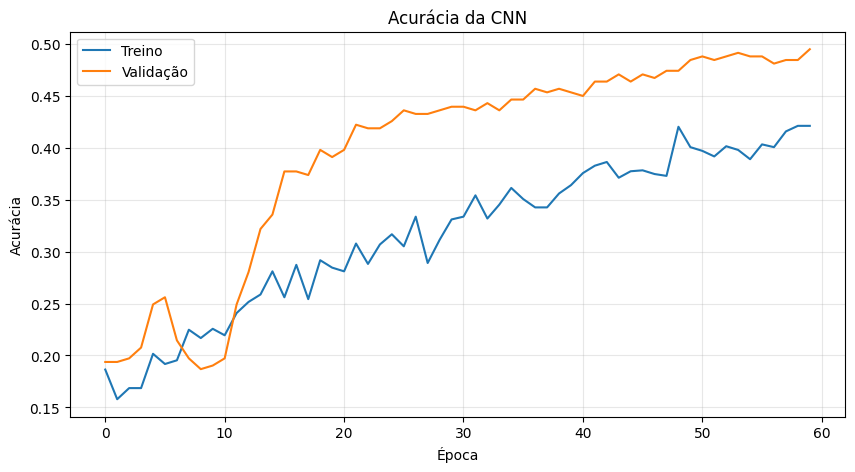

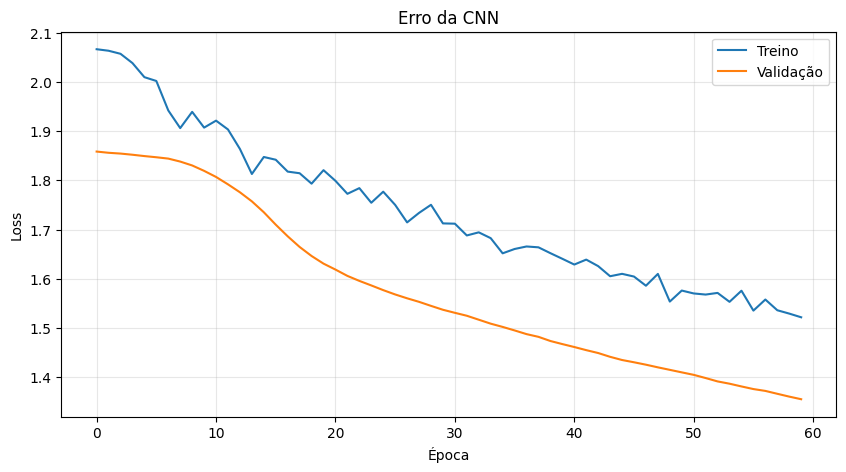

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(historico.history["accuracy"],label="Treino")
plt.plot(historico.history["val_accuracy"],label="Validação")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Acurácia da CNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(historico.history["loss"],label="Treino")
plt.plot(historico.history["val_loss"],label="Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Erro da CNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
lossTeste, acuraciaTeste = modelo.evaluate(teste)

print(f"Loss: {lossTeste:.4f}")
print(f"Acurácia: {acuraciaTeste * 100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - accuracy: 0.7163 - loss: 0.7866
Loss: 0.7866
Acurácia: 71.63%


In [ ]:
modelo.save(DATA_PATH + "/tattogyn2.keras")

In [6]:
modelo_loaded = tf.keras.models.load_model(DATA_PATH + "/tattogyn2.keras")
modelo_loaded.summary()
modelo_loaded.save_weights(DATA_PATH + "/tattogyn2.weights.h5")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,355,476 (295.09 MB)

 Trainable params: 25,785,158 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 51,570,318 (196.73 MB)